### 第11章 图像金字塔
#### 11.1 高斯金字塔
- 图像金字塔是由一幅图像的多个不同分辨率的子图所构成的图像集合，改组图像由单个图像通过不断降采样产生
- 通常情况下，图像金字塔的底部是高分辨率的原始图像，而顶部则为低分辨率的近似图像，每向上移动一级，图像的宽和高都降为原来的二分之一
- 在向下采样过程中，通常先对原始图像滤波，得到原始图像的近似图像，然后再将近似图像的偶数行和偶数列删除，获取下采样的结果
    - 滤波一方面能够有效地去噪，另一方面能让每个像素点包含临近点的信息，在下采样过程中尽量减少信息损耗。
    - 有多种滤波器可以选择，比如：
        - 邻域滤波器：采用邻域平均技术获得原始图像的近似图像，该方法产生平均金字塔
        - 高斯滤波器：采用高斯滤波器对原始图像进行滤波，得到高斯金字塔，也是`cv2.pyrDown()`采用的方式
- 对于向上采样过程，图像的宽度和高度变为原来的2倍，常用补零的方式完成插值，即每个像素点的右侧和下方插入零值的列和行，再使用高斯滤波器对补零后的图像进行滤波处理，得到上采样的结果图像。由于像素均值只有原来的四分之一，图像变暗了，为了保证上采样图像的像素值范围与原图像保持一致，通常将高斯滤波器的系数乘以4。
- 向上采样和向下采样是相反的两种操作，但由于下采样会丢失像素值，这两种操作不是可逆的。

- `dst = cv2.pyrDown(src[, dstsize[, bordeType]])`实现图像高斯金字塔操作中的下采样，其中
    - dst 为目标图像；src 为原始图像
    - dstsize 是目标图像的大小，默认情况下输出图像的大小为$\left(\mathrm(src.cols)+1/2, \mathrm(src.rows)+1/2 \right)$
    - borderTyper 是边界类型，这里仅支持默认值`BORDER_DEFAULT`
- `dst = cv2.pyrUp(src[, dstsize[, bordeType]])`实现图像高斯金字塔操作中的上采样，其中
    - dst 为目标图像；src 为原始图像
    - dstsize 是目标图像的大小，默认情况下输出图像的大小为$\left(\mathrm(src.cols)*2, \mathrm(src.rows)*2 \right)$
    - borderTyper 是边界类型，这里仅支持默认值`BORDER_DEFAULT`

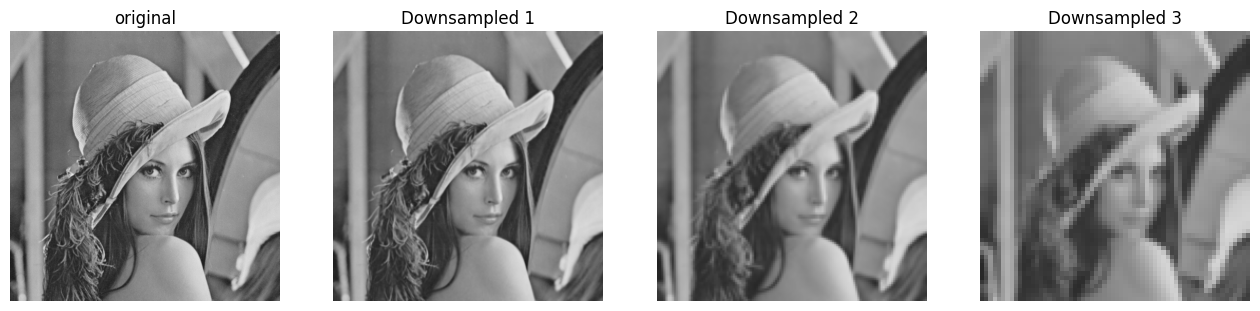

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
o = cv2.imread("lena.bmp", cv2.IMREAD_GRAYSCALE)
r1 = cv2.pyrDown(o)
r2 = cv2.pyrDown(r1)
r3 = cv2.pyrDown(r2)

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
r1 = cv2.cvtColor(r1, cv2.COLOR_BGR2RGB)
r2 = cv2.cvtColor(r2, cv2.COLOR_BGR2RGB)
r3 = cv2.cvtColor(r3, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 6))
plt.subplot(141)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(142)
plt.imshow(r1)
plt.title("Downsampled 1")
plt.axis("off")
plt.subplot(143)
plt.imshow(r2)
plt.title("Downsampled 2")
plt.axis("off")
plt.subplot(144)
plt.imshow(r3)
plt.title("Downsampled 3")
plt.axis("off")
plt.show()

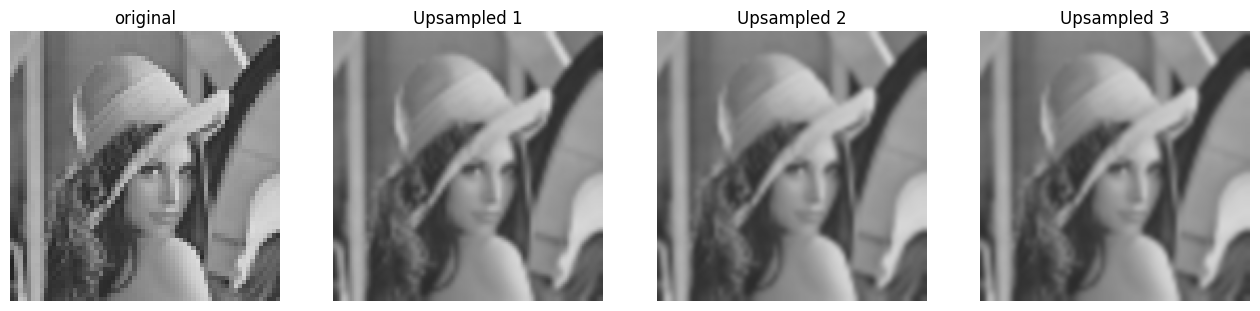

In [3]:
import cv2
o = cv2.imread("lenas.bmp")
r1 = cv2.pyrUp(o)
r2 = cv2.pyrUp(r1)
r3 = cv2.pyrUp(r2)

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
r1 = cv2.cvtColor(r1, cv2.COLOR_BGR2RGB)
r2 = cv2.cvtColor(r2, cv2.COLOR_BGR2RGB)
r3 = cv2.cvtColor(r3, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 6))
plt.subplot(141)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(142)
plt.imshow(r1)
plt.title("Upsampled 1")
plt.axis("off")
plt.subplot(143)
plt.imshow(r2)
plt.title("Upsampled 2")
plt.axis("off")
plt.subplot(144)
plt.imshow(r3)
plt.title("Upsampled 3")
plt.axis("off")
plt.show()

#### 11.2 上采样和下采样的差异性

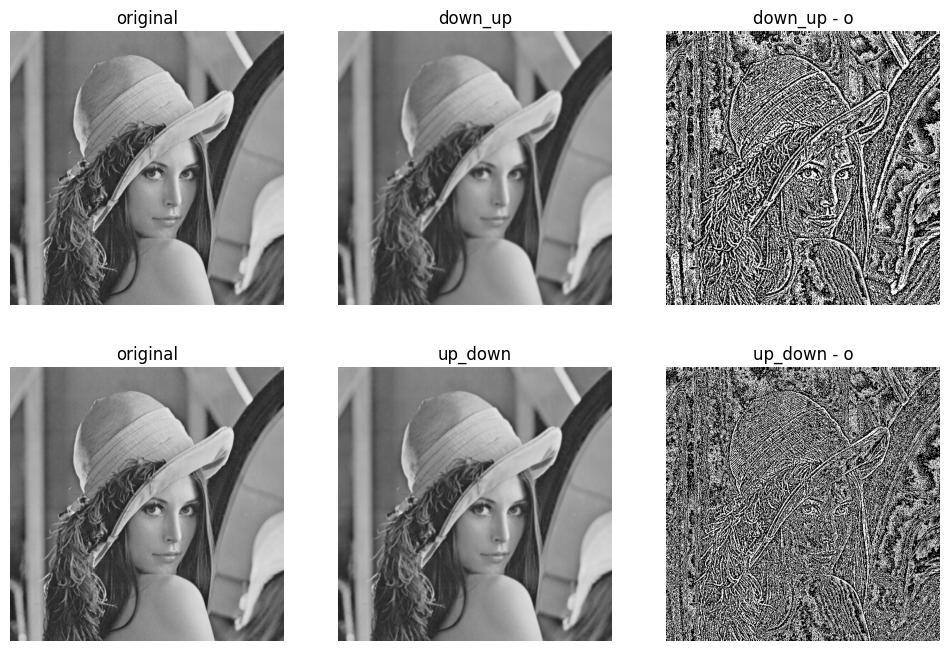

In [11]:
import cv2
o = cv2.imread("lena.bmp")
down = cv2.pyrDown(o)
down_up = cv2.pyrUp(down)
diff1 = down_up - o   # 先下采样，后上采样，计算up - o的差异

o = cv2.imread("lena.bmp")
up = cv2.pyrUp(o)
up_down = cv2.pyrDown(up)
diff2 = up_down-o   # 先上采样，后下采样，计算down - o的差异

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
down_up = cv2.cvtColor(down_up, cv2.COLOR_BGR2RGB)
diff1 = cv2.cvtColor(diff1, cv2.COLOR_BGR2RGB)
up_down = cv2.cvtColor(up_down, cv2.COLOR_BGR2RGB)
diff2 = cv2.cvtColor(diff2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(232)
plt.imshow(down_up)
plt.title("down_up")
plt.axis("off")
plt.subplot(233)
plt.imshow(diff1)
plt.title("down_up - o")
plt.axis("off")

plt.subplot(234)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(235)
plt.imshow(up_down)
plt.title("up_down")
plt.axis("off")
plt.subplot(236)
plt.imshow(diff2)
plt.title("up_down - o")
plt.axis("off")

plt.show()

#### 11.3 拉普拉斯金字塔
- 为了在上采样时能够恢复较高分辨率的原始图像，需要获取在采样过程中丢失的信息，这些丢失的信息就构成了拉普拉斯金字塔
$$ L_{i} = G_{i} - \mathrm{pyrUp}(G_{i+1}) $$

L0.shape= (512, 512, 3)
L1.shape= (256, 256, 3)
L2.shape= (128, 128, 3)


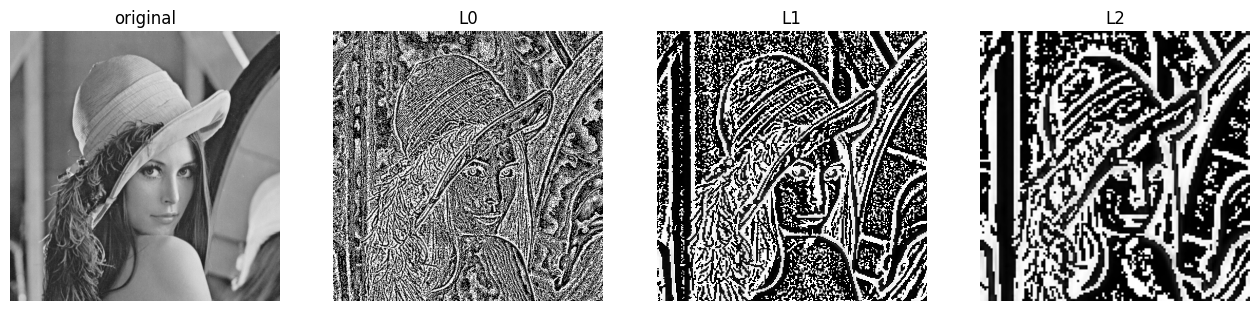

In [ ]:
import cv2
O = cv2.imread("lena.bmp")
G0 = O
G1 = cv2.pyrDown(G0)
G2 = cv2.pyrDown(G1)
G3 = cv2.pyrDown(G2)
L0 = G0 - cv2.pyrUp(G1) # 构造L0图像，查看G0与上采样后的G1的区别
L1 = G1 - cv2.pyrUp(G2) # 构造L1图像，查看G1与上采样后的G2的区别
L2 = G2 - cv2.pyrUp(G3) # 构造L2图像，查看G2与上采样后的G3的区别
print("L0.shape=", L0.shape)
print("L1.shape=", L1.shape)
print("L2.shape=", L2.shape)

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
L0 = cv2.cvtColor(L0, cv2.COLOR_BGR2RGB)
L1 = cv2.cvtColor(L1, cv2.COLOR_BGR2RGB)
L2 = cv2.cvtColor(L2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 6))
plt.subplot(141)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(142)
plt.imshow(L0)
plt.title("L0")
plt.axis("off")
plt.subplot(143)
plt.imshow(L1)
plt.title("L1")
plt.axis("off")
plt.subplot(144)
plt.imshow(L2)
plt.title("L2")
plt.axis("off")
plt.show()

In [14]:
# 通过拉普拉斯金字塔复原图像
import cv2
import numpy as np
O=cv2.imread("lena.bmp")
# =================生成高斯金字塔====================== # 
G0 = O
G1 = cv2.pyrDown(G0)
G2 = cv2.pyrDown(G1)
G3 = cv2.pyrDown(G2)
# ===============生成拉普拉斯金字塔==================== # 
L0 = G0 - cv2.pyrUp(G1) # 拉普拉斯金字塔第0层
L1 = G1 - cv2.pyrUp(G2) # 拉普拉斯金字塔第1层
L2 = G2 - cv2.pyrUp(G3) # 拉普拉斯金字塔第2层
# =================复原G0====================== #
RG0 = L0 + cv2.pyrUp(G1)  #通过拉普拉斯图像复原的原始图像G0
print("G0.shape=", G0.shape)
print("RG0.shape=", RG0.shape)
result = RG0 - G0  # 计算 RG0 和 G0 的差异
result=abs(result)  # # 计算result的绝对值，避免差值为负数时相互抵消
print("原始图像G0与恢复图像RG0差值的绝对值之和为：", np.sum(result)) #计算result所有元素的和
#=================复原G1======================
RG1 = L1 + cv2.pyrUp(G2) #通过拉普拉斯图像复原G1
print("G1.shape=", G1.shape)
print("RG1.shape=", RG1.shape)
result = RG1 - G1  # 计算 RG1 和 G1 的差异
print("原始图像G1与恢复图像RG1差值的绝对值之和为：", np.sum(abs(result)))
#=================复原G2======================
RG2 = L2 + cv2.pyrUp(G3) #通过拉普拉斯图像复原G2
print("G2.shape=", G2.shape)
print("RG2.shape=", RG2.shape)
result=RG2-G2  # 计算 RG2 和 G2 的差异
print("原始图像G2与恢复图像RG2差值的绝对值之和为：", np.sum(abs(result)))

G0.shape= (512, 512, 3)
RG0.shape= (512, 512, 3)
原始图像G0与恢复图像RG0差值的绝对值之和为： 0
G1.shape= (256, 256, 3)
RG1.shape= (256, 256, 3)
原始图像G1与恢复图像RG1差值的绝对值之和为： 0
G2.shape= (128, 128, 3)
RG2.shape= (128, 128, 3)
原始图像G2与恢复图像RG2差值的绝对值之和为： 0
